In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use('default')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
RESULTS_DIR = "/content/drive/MyDrive/Cloud anomaly detection/results/CORRELATION_ENGINE"

os.makedirs(RESULTS_DIR, exist_ok=True)

print("Correlation Engine folder ready:")
print(RESULTS_DIR)

Correlation Engine folder ready:
/content/drive/MyDrive/Cloud anomaly detection/results/CORRELATION_ENGINE


In [ ]:
AUTH_PATH = "/content/drive/MyDrive/Cloud anomaly detection/results/auth/auth_anomalies.csv"

API_PATH = "/content/drive/MyDrive/Cloud anomaly detection/results/API/api_anomalies.csv"

SYSTEM_PATH = "/content/drive/MyDrive/Cloud anomaly detection/results/SYSTEM_ANOMALITY/system_anomalies.csv"


auth_df = pd.read_csv(AUTH_PATH)
api_df = pd.read_csv(API_PATH)
system_df = pd.read_csv(SYSTEM_PATH)

print("Files loaded successfully.")

Files loaded successfully.


In [ ]:
print("="*60)
print("AUTH DATA")
print("="*60)

print(auth_df.shape)
print(auth_df.columns.tolist())

print("\n")

print("="*60)
print("API DATA")
print("="*60)

print(api_df.shape)
print(api_df.columns.tolist())

print("\n")

print("="*60)
print("SYSTEM DATA")
print("="*60)

print(system_df.shape)
print(system_df.columns.tolist())

AUTH DATA
(50000, 21)
['failed_attempts', 'session_duration', 'password_age_days', 'privilege_level', 'threat_level', 'hour', 'day_of_week', 'month', 'is_failed_login', 'mfa_disabled', 'token_expired_flag', 'blocked_flag', 'suspicious_flag', 'is_weekend', 'late_night_login', 'if_prediction', 'if_score', 'lof_prediction', 'lof_score', 'ensemble_anomaly', 'severity_score']


API DATA
(6851, 7)
['sourceIPAddress', 'if_anomaly', 'if_score', 'lof_anomaly', 'lof_score', 'final_anomaly', 'risk_score']


SYSTEM DATA
(405894, 23)
['avg_cpu', 'avg_memory', 'max_cpu', 'max_memory', 'sample_cpu', 'assigned_memory', 'page_cache_memory', 'cycles_per_instruction', 'memory_accesses_per_instruction', 'vertical_scaling', 'scheduler', 'priority', 'scheduling_class', 'failed', 'if_prediction', 'if_score', 'lof_prediction', 'lof_score', 'final_anomaly', 'if_score_scaled', 'lof_score_inverted', 'lof_score_scaled', 'risk_score']


In [ ]:
# ============================
# AUTH
# ============================

auth_total = len(auth_df)

auth_anomalies = auth_df[
    auth_df["ensemble_anomaly"] == 1
]

auth_count = len(auth_anomalies)

auth_pct = round(
    (auth_count / auth_total) * 100,
    2
)

auth_avg_risk = round(
    auth_anomalies["severity_score"].mean(),
    2
)

# ============================
# API
# ============================

api_total = len(api_df)

api_anomalies = api_df[
    api_df["final_anomaly"] == 1
]

api_count = len(api_anomalies)

api_pct = round(
    (api_count / api_total) * 100,
    2
)

api_avg_risk = round(
    api_anomalies["risk_score"].mean(),
    2
)

# ============================
# SYSTEM
# ============================

system_total = len(system_df)

system_anomalies = system_df[
    system_df["final_anomaly"] == 1
]

system_count = len(system_anomalies)

system_pct = round(
    (system_count / system_total) * 100,
    2
)

system_avg_risk = round(
    system_anomalies["risk_score"].mean(),
    2
)

print("Statistics extracted successfully.")

Statistics extracted successfully.


In [ ]:
print("="*60)
print("AUTH")
print("="*60)

print("Total Records:", auth_total)
print("Anomalies:", auth_count)
print("Percentage:", auth_pct)
print("Average Risk:", auth_avg_risk)

print()

print("="*60)
print("API")
print("="*60)

print("Total Records:", api_total)
print("Anomalies:", api_count)
print("Percentage:", api_pct)
print("Average Risk:", api_avg_risk)

print()

print("="*60)
print("SYSTEM")
print("="*60)

print("Total Records:", system_total)
print("Anomalies:", system_count)
print("Percentage:", system_pct)
print("Average Risk:", system_avg_risk)

AUTH
Total Records: 50000
Anomalies: 4556
Percentage: 9.11
Average Risk: -0.01

API
Total Records: 6851
Anomalies: 675
Percentage: 9.85
Average Risk: 0.64

SYSTEM
Total Records: 405894
Anomalies: 31579
Percentage: 7.78
Average Risk: 0.25


In [ ]:
correlation_summary = pd.DataFrame({
    "Source": [
        "Authentication",
        "API",
        "System"
    ],
    "Total_Records": [
        auth_total,
        api_total,
        system_total
    ],
    "Anomaly_Count": [
        auth_count,
        api_count,
        system_count
    ],
    "Anomaly_Percentage": [
        auth_pct,
        api_pct,
        system_pct
    ],
    "Average_Risk": [
        auth_avg_risk,
        api_avg_risk,
        system_avg_risk
    ]
})

correlation_summary

,Source,Total_Records,Anomaly_Count,Anomaly_Percentage,Average_Risk
0,Authentication,50000,4556,9.11,-0.01
1,API,6851,675,9.85,0.64
2,System,405894,31579,7.78,0.25


In [ ]:
correlation_summary = pd.DataFrame({
    "Source": [
        "Authentication",
        "API",
        "System"
    ],
    "Total_Records": [
        auth_total,
        api_total,
        system_total
    ],
    "Anomaly_Count": [
        auth_count,
        api_count,
        system_count
    ],
    "Anomaly_Percentage": [
        auth_pct,
        api_pct,
        system_pct
    ]
})

correlation_summary

,Source,Total_Records,Anomaly_Count,Anomaly_Percentage
0,Authentication,50000,4556,9.11
1,API,6851,675,9.85
2,System,405894,31579,7.78


In [ ]:
overall_cloud_risk = round(
    correlation_summary[
        "Anomaly_Percentage"
    ].mean() * 10,
    2
)

print("="*60)
print("UNIFIED CLOUD RISK SCORE")
print("="*60)
print("Cloud Risk Score:", overall_cloud_risk)

UNIFIED CLOUD RISK SCORE
Cloud Risk Score: 89.13


In [ ]:
if overall_cloud_risk < 25:
    risk_level = "LOW"

elif overall_cloud_risk < 50:
    risk_level = "MEDIUM"

elif overall_cloud_risk < 75:
    risk_level = "HIGH"

else:
    risk_level = "CRITICAL"

print("="*60)
print("OVERALL CLOUD RISK LEVEL")
print("="*60)
print(risk_level)

OVERALL CLOUD RISK LEVEL
CRITICAL


In [ ]:
correlation_summary["Cloud_Risk_Score"] = overall_cloud_risk
correlation_summary["Risk_Level"] = risk_level

correlation_summary

,Source,Total_Records,Anomaly_Count,Anomaly_Percentage,Cloud_Risk_Score,Risk_Level
0,Authentication,50000,4556,9.11,89.13,CRITICAL
1,API,6851,675,9.85,89.13,CRITICAL
2,System,405894,31579,7.78,89.13,CRITICAL


In [ ]:
summary_path = os.path.join(
    RESULTS_DIR,
    "correlation_summary.csv"
)

correlation_summary.to_csv(
    summary_path,
    index=False
)

print("Saved Successfully")
print(summary_path)

Saved Successfully
/content/drive/MyDrive/Cloud anomaly detection/results/CORRELATION_ENGINE/correlation_summary.csv


In [ ]:
dashboard_data = pd.DataFrame({
    "Metric": [
        "Auth_Anomalies",
        "API_Anomalies",
        "System_Anomalies",
        "Cloud_Risk_Score"
    ],
    "Value": [
        auth_count,
        api_count,
        system_count,
        overall_cloud_risk
    ]
})

dashboard_data

,Metric,Value
0,Auth_Anomalies,4556.00
1,API_Anomalies,675.00
2,System_Anomalies,31579.00
3,Cloud_Risk_Score,89.13


In [ ]:
dashboard_path = os.path.join(
    RESULTS_DIR,
    "dashboard_data.csv"
)

dashboard_data.to_csv(
    dashboard_path,
    index=False
)

print("Saved:")
print(dashboard_path)

Saved:
/content/drive/MyDrive/Cloud anomaly detection/results/CORRELATION_ENGINE/dashboard_data.csv


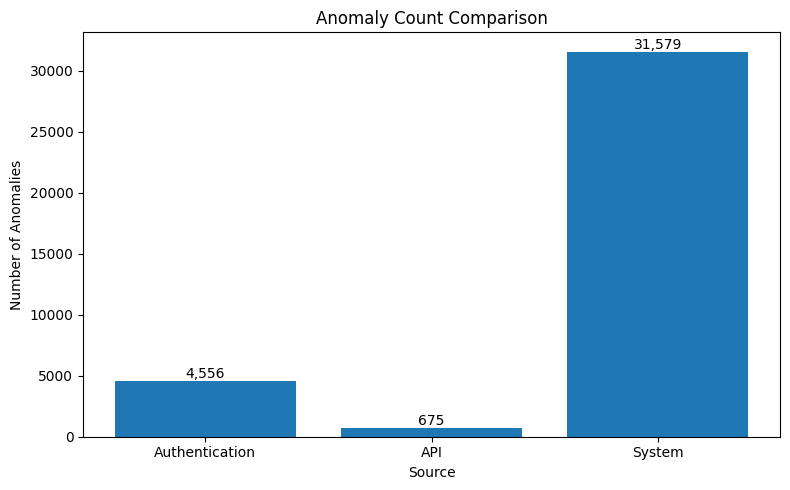

Saved: /content/drive/MyDrive/Cloud anomaly detection/results/CORRELATION_ENGINE/anomaly_count_comparison.png


In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    correlation_summary["Source"],
    correlation_summary["Anomaly_Count"]
)

plt.title("Anomaly Count Comparison")

plt.xlabel("Source")

plt.ylabel("Number of Anomalies")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()

save_path = os.path.join(
    RESULTS_DIR,
    "anomaly_count_comparison.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", save_path)

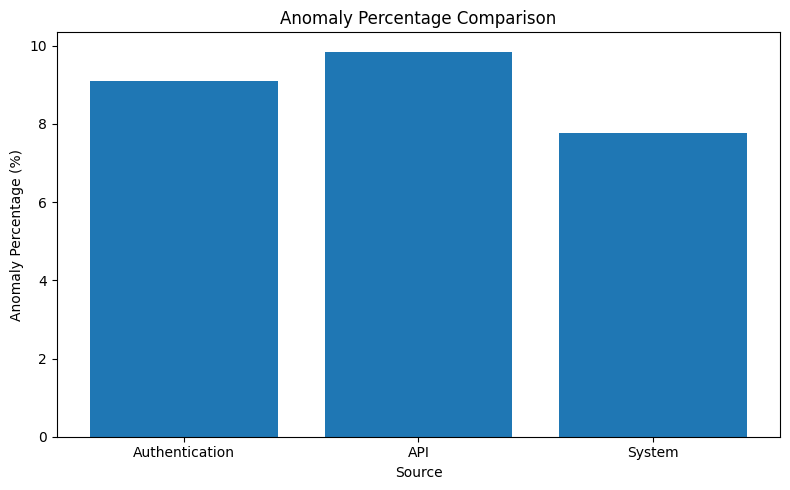

Saved: /content/drive/MyDrive/Cloud anomaly detection/results/CORRELATION_ENGINE/anomaly_percentage_comparison.png


In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    correlation_summary["Source"],
    correlation_summary["Anomaly_Percentage"]
)

plt.title("Anomaly Percentage Comparison")
plt.xlabel("Source")
plt.ylabel("Anomaly Percentage (%)")

plt.tight_layout()

save_path = os.path.join(
    RESULTS_DIR,
    "anomaly_percentage_comparison.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

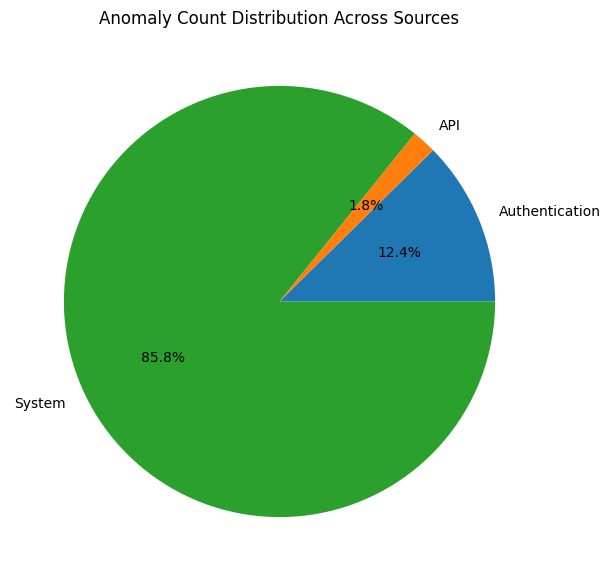

Saved: /content/drive/MyDrive/Cloud anomaly detection/results/CORRELATION_ENGINE/source_contribution_pie.png


In [ ]:
plt.figure(figsize=(7,7))

plt.pie(
    correlation_summary["Anomaly_Count"],
    labels=correlation_summary["Source"],
    autopct="%1.1f%%"
)

plt.title(
    "Anomaly Count Distribution Across Sources"
)

save_path = os.path.join(
    RESULTS_DIR,
    "source_contribution_pie.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

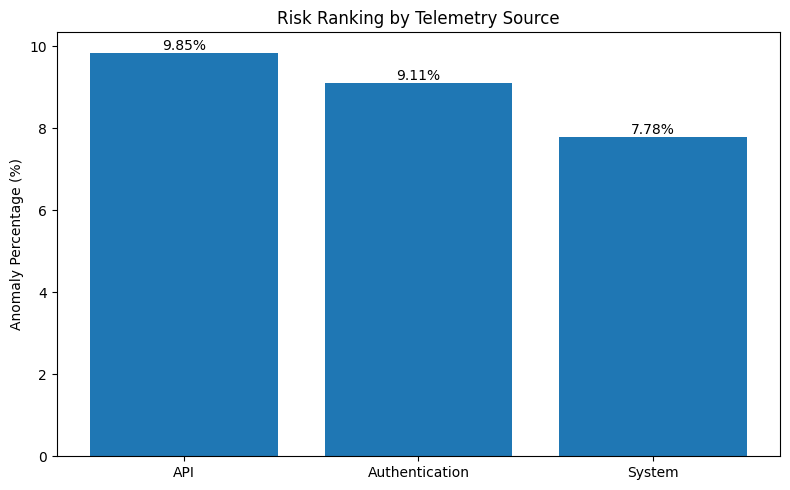

Saved: /content/drive/MyDrive/Cloud anomaly detection/results/CORRELATION_ENGINE/source_risk_ranking.png


In [ ]:
plt.figure(figsize=(8,5))

ranking = correlation_summary.sort_values(
    "Anomaly_Percentage",
    ascending=False
)

bars = plt.bar(
    ranking["Source"],
    ranking["Anomaly_Percentage"]
)

plt.title(
    "Risk Ranking by Telemetry Source"
)

plt.ylabel(
    "Anomaly Percentage (%)"
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

save_path = os.path.join(
    RESULTS_DIR,
    "source_risk_ranking.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", save_path)

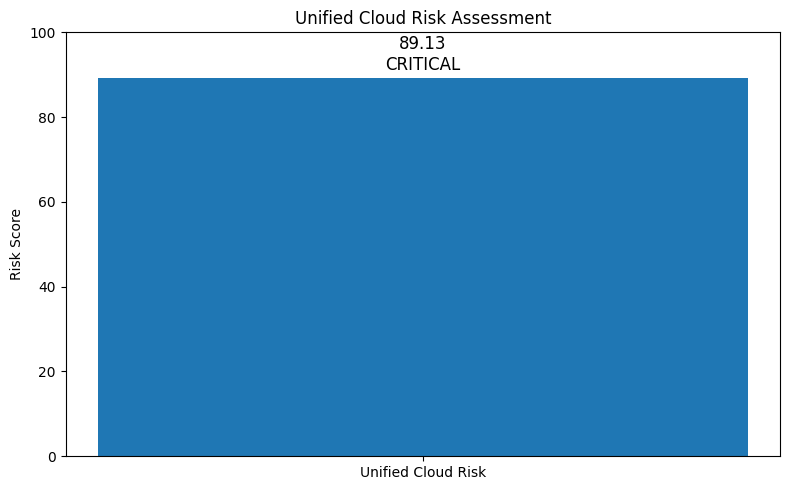

Saved: /content/drive/MyDrive/Cloud anomaly detection/results/CORRELATION_ENGINE/cloud_risk_score.png


In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    ["Unified Cloud Risk"],
    [overall_cloud_risk]
)

plt.ylim(0,100)

plt.ylabel("Risk Score")

plt.title("Unified Cloud Risk Assessment")

plt.text(
    0,
    overall_cloud_risk + 2,
    f"{overall_cloud_risk:.2f}\n{risk_level}",
    ha="center",
    fontsize=12
)

plt.tight_layout()

save_path = os.path.join(
    RESULTS_DIR,
    "cloud_risk_score.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", save_path)

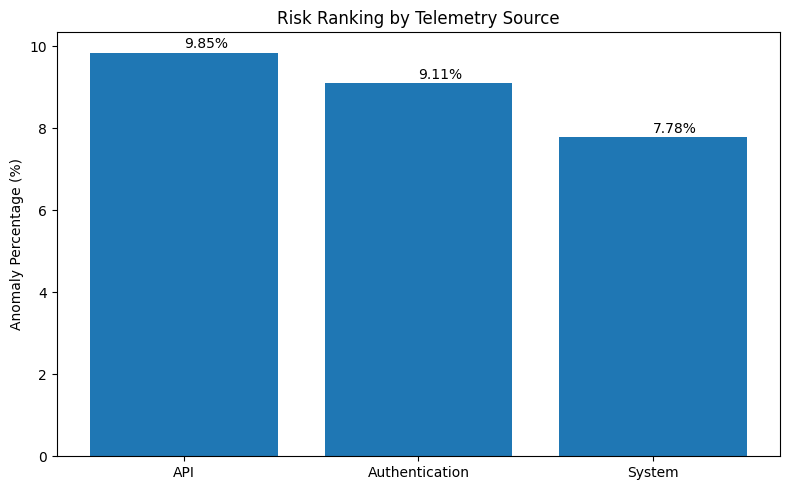

In [ ]:
plt.figure(figsize=(8,5))

ranking = correlation_summary.sort_values(
    "Anomaly_Percentage",
    ascending=False
)

plt.bar(
    ranking["Source"],
    ranking["Anomaly_Percentage"]
)

plt.title("Risk Ranking by Telemetry Source")
plt.ylabel("Anomaly Percentage (%)")

for i, v in enumerate(ranking["Anomaly_Percentage"]):
    plt.text(i, v + 0.1, f"{v:.2f}%")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "source_risk_ranking.png"
    ),
    dpi=300
)

plt.show()

In [ ]:
print("="*60)
print("CORRELATION ENGINE COMPLETED")
print("="*60)

print()

print("Cloud Risk Score :", overall_cloud_risk)
print("Risk Level       :", risk_level)

print()

print("Files Saved In:")
print(RESULTS_DIR)

CORRELATION ENGINE COMPLETED

Cloud Risk Score : 89.13
Risk Level       : CRITICAL

Files Saved In:
/content/drive/MyDrive/Cloud anomaly detection/results/CORRELATION_ENGINE


In [ ]:
summary_text = f"""
==================================================
CORRELATION ENGINE RESULTS
==================================================

Authentication Anomalies : {auth_count}
API Anomalies            : {api_count}
System Anomalies         : {system_count}

Authentication Rate (%) : {auth_pct}
API Rate (%)            : {api_pct}
System Rate (%)         : {system_pct}

Unified Cloud Risk Score : {overall_cloud_risk}

Risk Level : {risk_level}

==================================================
FILES GENERATED
==================================================

1. correlation_summary.csv
2. dashboard_data.csv

==================================================
FIGURES GENERATED
==================================================

1. anomaly_count_comparison.png
2. anomaly_percentage_comparison.png
3. source_contribution_pie.png
4. cloud_risk_score.png
5. source_risk_ranking.png

==================================================
"""

print(summary_text)


CORRELATION ENGINE RESULTS

Authentication Anomalies : 4556
API Anomalies            : 675
System Anomalies         : 31579

Authentication Rate (%) : 9.11
API Rate (%)            : 9.85
System Rate (%)         : 7.78

Unified Cloud Risk Score : 89.13

Risk Level : CRITICAL

FILES GENERATED

1. correlation_summary.csv
2. dashboard_data.csv

FIGURES GENERATED

1. anomaly_count_comparison.png
2. anomaly_percentage_comparison.png
3. source_contribution_pie.png
4. cloud_risk_score.png
5. source_risk_ranking.png




In [ ]:
report_path = os.path.join(
    RESULTS_DIR,
    "correlation_results_summary.txt"
)

with open(report_path, "w") as f:
    f.write(summary_text)

print("Saved:")
print(report_path)

Saved:
/content/drive/MyDrive/Cloud anomaly detection/results/CORRELATION_ENGINE/correlation_results_summary.txt
